# Neural Network Wind Farm Power Prediction

This notebook does the full required workflow:

1. Loads the same wind farm feature files and offshore `Power` target files as the decision tree version.
2. Trains **5 neural network models**, one per wind farm.
3. Saves the trained models as `.pkl` files in `models/saved/`.
4. Creates `src/predict_power.py` with the required function:

```python
predict_power(wind_farm_name, features_dict)
```

That function loads the correct saved model and returns a predicted power value in **MW**.

## Expected repo structure

Put this notebook in your main repo folder or in a `notebooks/` folder.

It expects these files:

```text
feature_engineering/features_Borssele_12.csv
feature_engineering/features_Borssele_34.csv
feature_engineering/features_Gemini.csv
feature_engineering/features_Hollandse_Kust_Noord.csv
feature_engineering/features_Hollandse_Kust_Zuid.csv

datasets_raw/offshore_dataset/Borssele_12.csv
datasets_raw/offshore_dataset/Borssele_34.csv
datasets_raw/offshore_dataset/Gemini.csv
datasets_raw/offshore_dataset/Hollandse_Kust_Noord.csv
datasets_raw/offshore_dataset/Hollandse_Kust_Zuid.csv
```

The offshore files need the columns `time` and `Power`.

In [1]:
from pathlib import Path
import warnings

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [10]:
from pathlib import Path

ROOT = Path.cwd().parent

WEATHER_DIR = ROOT / "datasets"
OFFSHORE_DIR = ROOT / "datasets_raw" / "offshore_dataset"
MODEL_DIR = ROOT / "models" / "trained_models"
SRC_DIR = ROOT / "models" / "src"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("WEATHER_DIR:", WEATHER_DIR)
print("OFFSHORE_DIR:", OFFSHORE_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("SRC_DIR:", SRC_DIR)


ROOT: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting
WEATHER_DIR: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\datasets
OFFSHORE_DIR: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\datasets_raw\offshore_dataset
MODEL_DIR: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\trained_models
SRC_DIR: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\src


In [4]:
import sys
sys.path.insert(0, str(ROOT))
from feature_engineering.weather_data_feature_engineering import engineer_features

FARMS_TO_TRAIN = [
    "Borssele_12",
    "Borssele_34",
    "Gemini",
    "Hollandse_Kust_Noord",
    "Hollandse_Kust_Zuid",
]

STATION_MAP = {
    "Borssele_12":          "Vlissingen",
    "Borssele_34":          "Vlissingen",
    "Gemini":               "Hoorn",
    "Hollandse_Kust_Zuid":  "Hoek_van_Holland",
    "Hollandse_Kust_Noord": "Hoek_van_Holland",
}

# Same feature columns used by the decision tree version.
FEATURES = [
    "wind_speed_hub_ms",
    "wind_power_density",
    "wind_dir_sin",
    "wind_dir_cos",
    "wind_speed_lag_1h",
    "wind_speed_lag_6h",
    "wind_speed_lag_24h",
    "wind_speed_roll_3h",
    "wind_speed_roll_24h",
    "pressure_hpa",
    "temperature_c",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
]

TARGET = "Power"


In [5]:
# Quick file check.
missing_files = []

for farm_id in FARMS_TO_TRAIN:
    station_id = STATION_MAP[farm_id]
    weather_file = WEATHER_DIR / f"knmi_{station_id}.csv"
    offshore_file = OFFSHORE_DIR / f"{farm_id}.csv"

    if not weather_file.exists():
        missing_files.append(str(weather_file))
    if not offshore_file.exists():
        missing_files.append(str(offshore_file))

if missing_files:
    print("Missing files:")
    for file in missing_files:
        print(" -", file)
else:
    print("All required files were found.")


All required files were found.


## Load and merge one farm

This function loads:

- `features_<farm>.csv` from `feature_engineering/`
- `<farm>.csv` from `datasets_raw/offshore_dataset/`

Then it joins the weather/engineered features with the real `Power` output.

In [6]:
def load_farm_data(farm_id):
    station_id = STATION_MAP[farm_id]
    weather_path = WEATHER_DIR / f"knmi_{station_id}.csv"
    offshore_path = OFFSHORE_DIR / f"{farm_id}.csv"

    weather_raw = pd.read_csv(weather_path, parse_dates=["timestamp"])

    # engineer_features expects: timestamp, wind_speed_ms, wind_direction_deg,
    # pressure_hpa, temperature_c. Applies farm-specific hub height scaling
    # and computes all 15 features, identical to what predict-time code uses.
    features = engineer_features(farm_id, weather_raw, return_all_rows=True)

    offshore = pd.read_csv(
        offshore_path,
        parse_dates=["time"],
        index_col="time"
    )

    if getattr(features.index, "tz", None) is not None:
        features.index = features.index.tz_localize(None)
    if getattr(offshore.index, "tz", None) is not None:
        offshore.index = offshore.index.tz_localize(None)

    merged = features.join(offshore[[TARGET]], how="inner")
    merged = merged.dropna(subset=[TARGET])

    missing_features = [col for col in FEATURES if col not in merged.columns]
    if missing_features:
        raise KeyError(f"{farm_id} is missing feature columns: {missing_features}")

    X = merged[FEATURES]
    y = merged[TARGET]

    return X, y, merged


In [7]:
# Test loading before training all models.
X_sample, y_sample, merged_sample = load_farm_data("Borssele_12")

print("Merged shape:", merged_sample.shape)
print("X shape:", X_sample.shape)
print("y shape:", y_sample.shape)
print("Power preview:")
display(y_sample.head())

Merged shape: (43824, 16)
X shape: (43824, 15)
y shape: (43824,)
Power preview:


timestamp
2015-01-01 00:00:00    752.00000
2015-01-01 01:00:00    752.00000
2015-01-01 02:00:00    752.00000
2015-01-01 03:00:00    752.00000
2015-01-01 04:00:00    725.54614
Name: Power, dtype: float64

## Train 5 neural network models

This creates one neural network per farm and saves it as:

```text
models/saved/neural_network_<farm_id>.pkl
```

In [14]:
results = {}

for farm_id in FARMS_TO_TRAIN:
    print("\n" + "=" * 60)
    print(f"Training Neural Network: {farm_id}")
    print("=" * 60)

    X, y, merged = load_farm_data(farm_id)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    nn_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42,
        )),
    ])

    nn_model.fit(X_train, y_train)
    y_pred = nn_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results[farm_id] = {
        "model": nn_model,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "rows": len(merged),
    }

    model_path = MODEL_DIR / f"neural_network_{farm_id}.pkl"

    joblib.dump(
        {
            "farm_id": farm_id,
            "model": nn_model,
            "features": FEATURES,
            "target": TARGET,
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
        },
        model_path
    )

    print(f"Rows used: {len(merged)}")
    print(f"Saved model to: {model_path}")
    print(f"MAE:  {mae:.2f} MW")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"R²:   {r2:.4f}")

print("\nTraining complete.")


Training Neural Network: Borssele_12
Rows used: 43824
Saved model to: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\trained_models\neural_network_Borssele_12.pkl
MAE:  102.92 MW
RMSE: 140.71 MW
R²:   0.7562

Training Neural Network: Borssele_34
Rows used: 43824
Saved model to: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\trained_models\neural_network_Borssele_34.pkl
MAE:  107.40 MW
RMSE: 143.21 MW
R²:   0.7185

Training Neural Network: Gemini
Rows used: 43824
Saved model to: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\trained_models\neural_network_Gemini.pkl
MAE:  72.20 MW
RMSE: 102.05 MW
R²:   0.7210

Training Neural Network: Hollandse_Kust_Noord
Rows used: 43824
Saved model to: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\trained_models\neural_network_Hollandse_Kust_Noord.pkl
MAE:  107.71 MW
RMSE: 148.76 MW
R²:   0.7196

Training Neural Network: Hollandse_Kust_Zuid
Rows used: 4382

In [11]:
summary_df = pd.DataFrame([
    {
        "farm_id": farm_id,
        "rows": values["rows"],
        "mae_mw": values["mae"],
        "rmse_mw": values["rmse"],
        "r2": values["r2"],
    }
    for farm_id, values in results.items()
])

summary_path = MODEL_DIR / "neural_network_results_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print("Saved summary to:", summary_path)

,farm_id,rows,mae_mw,rmse_mw,r2
0,Borssele_12,43824,102.923837,140.709217,0.756169
1,Borssele_34,43824,107.395985,143.211506,0.718472
2,Gemini,43824,72.203502,102.052326,0.720976
3,Hollandse_Kust_Noord,43824,107.710246,148.758776,0.719555
4,Hollandse_Kust_Zuid,43824,163.451367,233.659691,0.828918


Saved summary to: C:\Users\lackn\PycharmProjects\Offshore_Wind_Energy_Forecasting\models\trained_models\neural_network_results_summary.csv


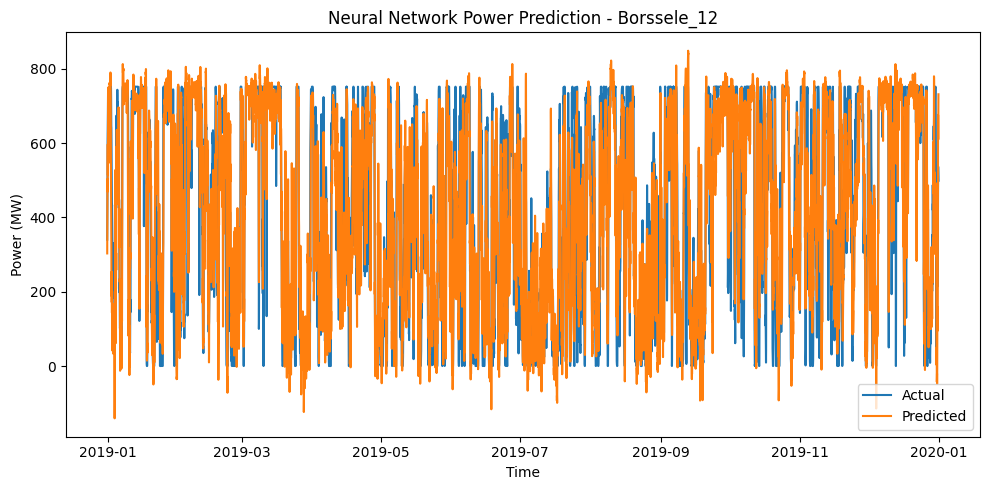

NameError: name 'plot_path' is not defined

In [13]:
# Plot actual vs predicted values for each farm.
for farm_id, values in results.items():
    y_test = values["y_test"]
    y_pred = values["y_pred"]

    plt.figure(figsize=(10, 5))
    plt.plot(y_test.index, y_test.values, label="Actual")
    plt.plot(y_test.index, y_pred, label="Predicted")
    plt.title(f"Neural Network Power Prediction - {farm_id}")
    plt.xlabel("Time")
    plt.ylabel("Power (MW)")
    plt.legend()
    plt.tight_layout()

    plt.show()

## Create `src/predict_power.py`

This creates the `.py` file required for the final implementation.

In [46]:
predict_power_code = '''"""
predict_power.py

Loads a saved neural network model for one offshore wind farm and returns a
predicted power value in MW.
"""

from pathlib import Path
from typing import Dict, Union

import joblib
import pandas as pd

Number = Union[int, float]

FARM_ALIASES = {
    "Borssele_12": "Borssele_12",
    "Borssele_34": "Borssele_34",
    "Gemini": "Gemini",
    "Hollandse_Kust_Noord": "Hollandse_Kust_Noord",
    "Hollandse_Kust_Zuid": "Hollandse_Kust_Zuid",
}


def _find_project_root() -> Path:
    current = Path(__file__).resolve()
    for parent in [current.parent, *current.parents]:
        if (parent / "models" / "saved").exists():
            return parent
    return Path(__file__).resolve().parents[1]


def predict_power(wind_farm_name: str, features_dict: Dict[str, Number]) -> float:
    """
    Predict offshore wind farm power output in MW.

    Parameters
    ----------
    wind_farm_name:
        One of: Borssele_12, Borssele_34, Gemini,
        Hollandse_Kust_Noord, Hollandse_Kust_Zuid.

    features_dict:
        Dictionary containing the model input features. Extra keys are ignored,
        but all required feature keys must be present.

    Returns
    -------
    float
        Predicted power output in MW.
    """
    if wind_farm_name not in FARM_ALIASES:
        valid = ", ".join(FARM_ALIASES.keys())
        raise ValueError(f"Unknown wind farm '{wind_farm_name}'. Valid names: {valid}")

    farm_id = FARM_ALIASES[wind_farm_name]
    root = _find_project_root()
    model_path = root / "models" / "saved" / f"neural_network_{farm_id}.pkl"

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model file not found: {model_path}
"
            "Run the neural network training notebook first so the .pkl models are created."
        )

    saved = joblib.load(model_path)
    model = saved["model"]
    feature_columns = saved["features"]

    missing = [col for col in feature_columns if col not in features_dict]
    if missing:
        raise ValueError(
            "Missing required features: " + ", ".join(missing) +
            "
Required features are: " + ", ".join(feature_columns)
        )

    X = pd.DataFrame([{col: features_dict[col] for col in feature_columns}])
    prediction_mw = float(model.predict(X)[0])

    return max(0.0, prediction_mw)
'''

predict_file = SRC_DIR / "predict_power.py"
predict_file.write_text(predict_power_code, encoding="utf-8")
print("Created:", predict_file)

Created: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (2)\Offshore_Wind_Energy_Forecasting-main\models\src\predict_power.py


## Test `predict_power(wind_farm_name, features_dict)`

This uses the first real Gemini row as an example input dictionary.

In [49]:
from pathlib import Path

predict_file = Path.cwd() / "src" / "predict_power.py"

fixed_code = '''from pathlib import Path
import joblib
import pandas as pd

FARMS = {
    "Borssele_12",
    "Borssele_34",
    "Gemini",
    "Hollandse_Kust_Noord",
    "Hollandse_Kust_Zuid",
}


def predict_power(wind_farm_name, features_dict):
    if wind_farm_name not in FARMS:
        raise ValueError(f"Unknown wind farm: {wind_farm_name}")

    root = Path(__file__).resolve().parents[2]

    model_path = root / "models" / "saved" / f"neural_network_{wind_farm_name}.pkl"

    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    saved = joblib.load(model_path)
    model = saved["model"]
    feature_columns = saved["features"]

    row = {}
    for col in feature_columns:
        if col not in features_dict:
            raise ValueError(f"Missing required feature: {col}")
        row[col] = features_dict[col]

    X = pd.DataFrame([row])
    prediction = float(model.predict(X)[0])

    return max(0.0, prediction)
'''

predict_file.write_text(fixed_code, encoding="utf-8")

print("Overwritten:", predict_file)
print("Exists:", predict_file.exists())

Overwritten: C:\Users\ralph\Downloads\Offshore_Wind_Energy_Forecasting-main (2)\Offshore_Wind_Energy_Forecasting-main\models\src\predict_power.py
Exists: True


In [50]:
import sys
from pathlib import Path

src_path = Path.cwd() / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from predict_power import predict_power

print("predict_power imported successfully.")

predict_power imported successfully.


In [51]:
import sys

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from predict_power import predict_power

example_X, _, _ = load_farm_data("Gemini")
example_features_dict = example_X.iloc[0].to_dict()

prediction = predict_power("Gemini", example_features_dict)
print(f"Predicted Gemini power: {prediction:.2f} MW")

Predicted Gemini power: 535.27 MW


## Example of manual function usage

This is how the rest of the project can call the prediction function after the models are trained.

In [52]:
example_features = {
    "wind_speed_hub_ms": 12.5,
    "wind_power_density": 680.0,
    "wind_dir_sin": 0.2,
    "wind_dir_cos": 0.98,
    "wind_speed_lag_1h": 12.0,
    "wind_speed_lag_6h": 11.5,
    "wind_speed_lag_24h": 9.8,
    "wind_speed_roll_3h": 12.2,
    "wind_speed_roll_24h": 10.1,
    "pressure_hpa": 1013.2,
    "temperature_c": 9.5,
    "month_sin": 0.5,
    "month_cos": 0.866,
    "hour_sin": 0.0,
    "hour_cos": 1.0,
}

# prediction = predict_power("Gemini", example_features)
# print(prediction)